In [1]:
%pip install shap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.9/59.9 MB 33.6 MB/s  0:00:016m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 26.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [shap]4/5 [shap]]te]
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupKFold
from xgboost import XGBRegressor

/usr/local/python/3.14.2/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
df = pd.read_csv("../data/processed/concrete_clean.csv")

df.shape

(1005, 11)

In [4]:
feature_cols = [
    'cement',
    'slag',
    'fly_ash',
    'water',
    'superplasticizer',
    'coarse_aggregate',
    'fine_aggregate'
]

stage_order = ['Early', '28-day', 'Later']

In [5]:
xgb_params = {
    'n_estimators': 300,
    'learning_rate': 0.05,
    'max_depth': 3,
    'random_state': 42,
    'n_jobs': -1,
    'objective': 'reg:squarederror'
}

In [6]:
stage = 'Early'

stage_df = df[df['age_stage'] == stage].copy()

X = stage_df[feature_cols]
y = stage_df['strength']
groups = stage_df['mix_id']

print("Stage:", stage)
print("Rows:", len(stage_df))
print("Unique mix IDs:", groups.nunique())

Stage: Early
Rows: 315
Unique mix IDs: 183


In [7]:
gkf = GroupKFold(n_splits=5)

early_oof_shap = np.zeros(
    (len(stage_df), len(feature_cols))
)

In [8]:
for fold, (train_idx, val_idx) in enumerate(
    gkf.split(X, y, groups=groups),
    start=1
):

    X_train = X.iloc[train_idx]
    X_val = X.iloc[val_idx]

    y_train = y.iloc[train_idx]

    model = XGBRegressor(**xgb_params)

    model.fit(X_train, y_train)

    explainer = shap.TreeExplainer(model)

    shap_values = explainer.shap_values(X_val)

    early_oof_shap[val_idx, :] = shap_values

    print(f"Fold {fold} completed")

Fold 1 completed
Fold 2 completed
Fold 3 completed
Fold 4 completed
Fold 5 completed


In [9]:
early_oof_shap.shape

(315, 7)

In [10]:
early_mean_abs_shap = np.abs(early_oof_shap).mean(axis=0)

early_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Mean_Abs_SHAP': early_mean_abs_shap
})

early_importance

,Feature,Mean_Abs_SHAP
0,cement,5.014916
1,slag,0.546527
2,fly_ash,0.408823
3,water,2.211387
4,superplasticizer,3.128068
5,coarse_aggregate,0.702046
6,fine_aggregate,1.474698


In [11]:
early_importance = early_importance.sort_values(
    'Mean_Abs_SHAP',
    ascending=False
).reset_index(drop=True)

early_importance

,Feature,Mean_Abs_SHAP
0,cement,5.014916
1,superplasticizer,3.128068
2,water,2.211387
3,fine_aggregate,1.474698
4,coarse_aggregate,0.702046
5,slag,0.546527
6,fly_ash,0.408823


In [12]:
early_importance['Relative_Importance_%'] = (
    early_importance['Mean_Abs_SHAP']
    / early_importance['Mean_Abs_SHAP'].sum()
    * 100
)

early_importance

,Feature,Mean_Abs_SHAP,Relative_Importance_%
0,cement,5.014916,37.184805
1,superplasticizer,3.128068,23.194131
2,water,2.211387,16.397083
3,fine_aggregate,1.474698,10.934653
4,coarse_aggregate,0.702046,5.205559
5,slag,0.546527,4.052413
6,fly_ash,0.408823,3.031356


In [13]:
early_importance['Relative_Importance_%'].sum()

np.float64(100.0)

In [14]:
early_importance['Rank'] = range(
    1,
    len(early_importance) + 1
)

early_importance

,Feature,Mean_Abs_SHAP,Relative_Importance_%,Rank
0,cement,5.014916,37.184805,1
1,superplasticizer,3.128068,23.194131,2
2,water,2.211387,16.397083,3
3,fine_aggregate,1.474698,10.934653,4
4,coarse_aggregate,0.702046,5.205559,5
5,slag,0.546527,4.052413,6
6,fly_ash,0.408823,3.031356,7


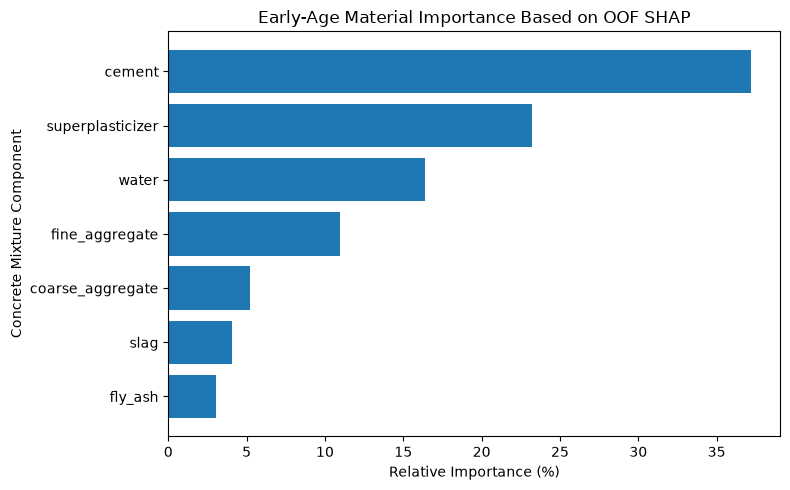

In [15]:
plt.figure(figsize=(8,5))

plt.barh(
    early_importance['Feature'][::-1],
    early_importance['Relative_Importance_%'][::-1]
)

plt.xlabel('Relative Importance (%)')
plt.ylabel('Concrete Mixture Component')
plt.title('Early-Age Material Importance Based on OOF SHAP')
plt.tight_layout()
plt.show()

In [16]:
stage = '28-day'

stage_df = df[df['age_stage'] == stage].copy()

X = stage_df[feature_cols]
y = stage_df['strength']
groups = stage_df['mix_id']

print("Stage:", stage)
print("Rows:", len(stage_df))
print("Unique mix IDs:", groups.nunique())

Stage: 28-day
Rows: 419
Unique mix IDs: 417


In [17]:
gkf = GroupKFold(n_splits=5)

day28_oof_shap = np.zeros(
    (len(stage_df), len(feature_cols))
)

In [18]:
for fold, (train_idx, val_idx) in enumerate(
    gkf.split(X, y, groups=groups),
    start=1
):

    X_train = X.iloc[train_idx]
    X_val = X.iloc[val_idx]

    y_train = y.iloc[train_idx]

    model = XGBRegressor(**xgb_params)

    model.fit(X_train, y_train)

    explainer = shap.TreeExplainer(model)

    shap_values = explainer.shap_values(X_val)

    day28_oof_shap[val_idx, :] = shap_values

    print(f"Fold {fold} completed")

Fold 1 completed
Fold 2 completed
Fold 3 completed
Fold 4 completed
Fold 5 completed


In [19]:
day28_oof_shap.shape

(419, 7)

In [20]:
day28_mean_abs_shap = np.abs(day28_oof_shap).mean(axis=0)

day28_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Mean_Abs_SHAP': day28_mean_abs_shap
})

day28_importance = day28_importance.sort_values(
    'Mean_Abs_SHAP',
    ascending=False
).reset_index(drop=True)

In [21]:
day28_importance['Relative_Importance_%'] = (
    day28_importance['Mean_Abs_SHAP']
    / day28_importance['Mean_Abs_SHAP'].sum()
    * 100
)

day28_importance['Rank'] = range(
    1,
    len(day28_importance) + 1
)

day28_importance

,Feature,Mean_Abs_SHAP,Relative_Importance_%,Rank
0,cement,8.641958,40.800424,1
1,slag,4.804413,22.682600,2
2,water,4.010447,18.934128,3
3,superplasticizer,1.360153,6.421554,4
4,fine_aggregate,0.958427,4.524928,5
5,coarse_aggregate,0.944827,4.460719,6
6,fly_ash,0.460825,2.175648,7


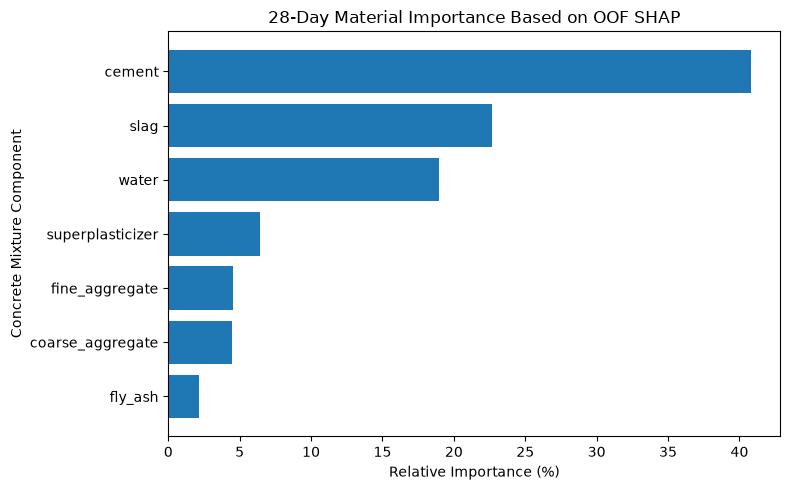

In [22]:
plt.figure(figsize=(8,5))

plt.barh(
    day28_importance['Feature'][::-1],
    day28_importance['Relative_Importance_%'][::-1]
)

plt.xlabel('Relative Importance (%)')
plt.ylabel('Concrete Mixture Component')
plt.title('28-Day Material Importance Based on OOF SHAP')
plt.tight_layout()
plt.show()

In [23]:
stage = 'Later'

stage_df = df[df['age_stage'] == stage].copy()

X = stage_df[feature_cols]
y = stage_df['strength']
groups = stage_df['mix_id']

print("Stage:", stage)
print("Rows:", len(stage_df))
print("Unique mix IDs:", groups.nunique())

Stage: Later
Rows: 271
Unique mix IDs: 140


In [24]:
gkf = GroupKFold(n_splits=5)

later_oof_shap = np.zeros(
    (len(stage_df), len(feature_cols))
)

In [25]:
for fold, (train_idx, val_idx) in enumerate(
    gkf.split(X, y, groups=groups),
    start=1
):

    X_train = X.iloc[train_idx]
    X_val = X.iloc[val_idx]

    y_train = y.iloc[train_idx]

    model = XGBRegressor(**xgb_params)

    model.fit(X_train, y_train)

    explainer = shap.TreeExplainer(model)

    shap_values = explainer.shap_values(X_val)

    later_oof_shap[val_idx, :] = shap_values

    print(f"Fold {fold} completed")

Fold 1 completed
Fold 2 completed
Fold 3 completed
Fold 4 completed
Fold 5 completed


In [26]:
later_oof_shap.shape

(271, 7)

In [27]:
later_mean_abs_shap = np.abs(later_oof_shap).mean(axis=0)

later_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Mean_Abs_SHAP': later_mean_abs_shap
})

later_importance = later_importance.sort_values(
    'Mean_Abs_SHAP',
    ascending=False
).reset_index(drop=True)

In [28]:
later_importance['Relative_Importance_%'] = (
    later_importance['Mean_Abs_SHAP']
    / later_importance['Mean_Abs_SHAP'].sum()
    * 100
)

later_importance['Rank'] = range(
    1,
    len(later_importance) + 1
)

later_importance

,Feature,Mean_Abs_SHAP,Relative_Importance_%,Rank
0,superplasticizer,5.431285,30.665116,1
1,fine_aggregate,3.285926,18.552385,2
2,cement,3.006153,16.972781,3
3,water,2.715969,15.334404,4
4,slag,2.011362,11.356178,5
5,coarse_aggregate,0.723841,4.086818,6
6,fly_ash,0.537072,3.032318,7


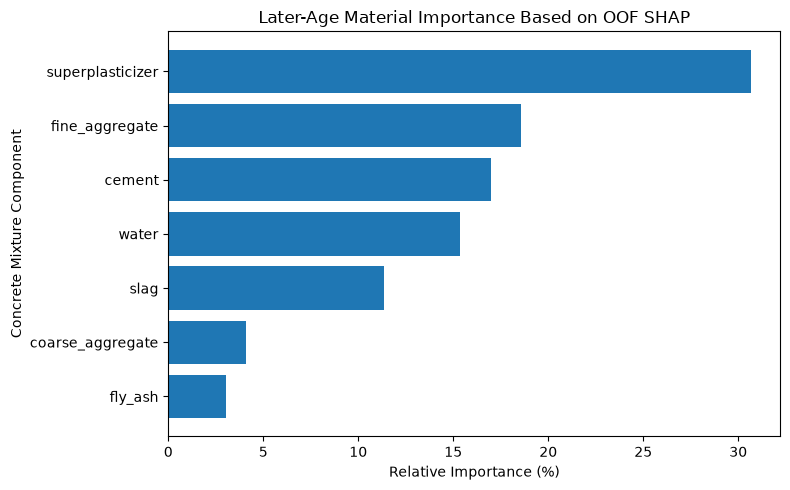

In [29]:
plt.figure(figsize=(8,5))

plt.barh(
    later_importance['Feature'][::-1],
    later_importance['Relative_Importance_%'][::-1]
)

plt.xlabel('Relative Importance (%)')
plt.ylabel('Concrete Mixture Component')
plt.title('Later-Age Material Importance Based on OOF SHAP')
plt.tight_layout()
plt.show()

In [30]:
comparison = (
    early_importance[['Feature', 'Relative_Importance_%']]
    .rename(columns={'Relative_Importance_%': 'Early'})
    .merge(
        day28_importance[['Feature', 'Relative_Importance_%']]
        .rename(columns={'Relative_Importance_%': '28-day'}),
        on='Feature'
    )
    .merge(
        later_importance[['Feature', 'Relative_Importance_%']]
        .rename(columns={'Relative_Importance_%': 'Later'}),
        on='Feature'
    )
)

comparison

,Feature,Early,28-day,Later
0,cement,37.184805,40.800424,16.972781
1,superplasticizer,23.194131,6.421554,30.665116
2,water,16.397083,18.934128,15.334404
3,fine_aggregate,10.934653,4.524928,18.552385
4,coarse_aggregate,5.205559,4.460719,4.086818
5,slag,4.052413,22.682600,11.356178
6,fly_ash,3.031356,2.175648,3.032318


In [31]:
comparison['Average_Importance'] = comparison[
    ['Early', '28-day', 'Later']
].mean(axis=1)

comparison = comparison.sort_values(
    'Average_Importance',
    ascending=False
).reset_index(drop=True)

comparison

,Feature,Early,28-day,Later,Average_Importance
0,cement,37.184805,40.800424,16.972781,31.652670
1,superplasticizer,23.194131,6.421554,30.665116,20.093600
2,water,16.397083,18.934128,15.334404,16.888538
3,slag,4.052413,22.682600,11.356178,12.697063
4,fine_aggregate,10.934653,4.524928,18.552385,11.337322
5,coarse_aggregate,5.205559,4.460719,4.086818,4.584365
6,fly_ash,3.031356,2.175648,3.032318,2.746441


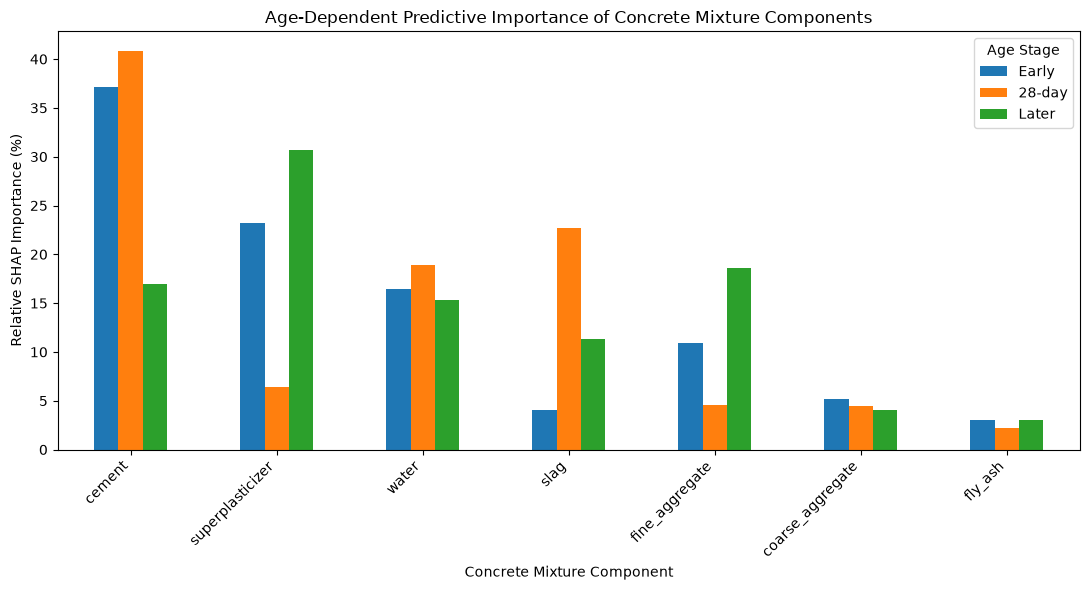

In [32]:
comparison_plot = comparison.set_index('Feature')[
    ['Early', '28-day', 'Later']
]

comparison_plot.plot(
    kind='bar',
    figsize=(11,6)
)

plt.title('Age-Dependent Predictive Importance of Concrete Mixture Components')
plt.xlabel('Concrete Mixture Component')
plt.ylabel('Relative SHAP Importance (%)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Age Stage')
plt.tight_layout()
plt.show()

In [33]:
rank_comparison = comparison[['Feature', 'Early', '28-day', 'Later']].copy()

rank_comparison['Early_Rank'] = (
    rank_comparison['Early'].rank(ascending=False, method='min').astype(int)
)

rank_comparison['28-day_Rank'] = (
    rank_comparison['28-day'].rank(ascending=False, method='min').astype(int)
)

rank_comparison['Later_Rank'] = (
    rank_comparison['Later'].rank(ascending=False, method='min').astype(int)
)

rank_comparison

,Feature,Early,28-day,Later,Early_Rank,28-day_Rank,Later_Rank
0,cement,37.184805,40.800424,16.972781,1,1,3
1,superplasticizer,23.194131,6.421554,30.665116,2,4,1
2,water,16.397083,18.934128,15.334404,3,3,4
3,slag,4.052413,22.682600,11.356178,6,2,5
4,fine_aggregate,10.934653,4.524928,18.552385,4,5,2
5,coarse_aggregate,5.205559,4.460719,4.086818,5,6,6
6,fly_ash,3.031356,2.175648,3.032318,7,7,7


In [34]:
comparison.to_csv(
    "../data/processed/shap_stage_comparison.csv",
    index=False
)

rank_comparison.to_csv(
    "../data/processed/shap_rank_comparison.csv",
    index=False
)

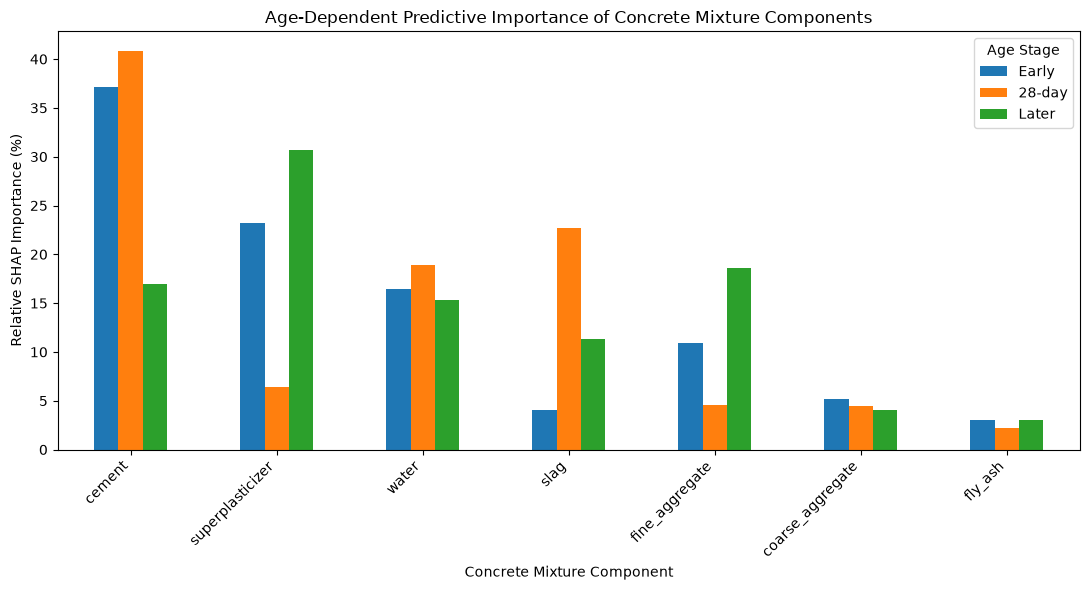

In [35]:
comparison_plot = comparison.set_index('Feature')[
    ['Early', '28-day', 'Later']
]

comparison_plot.plot(
    kind='bar',
    figsize=(11,6)
)

plt.title('Age-Dependent Predictive Importance of Concrete Mixture Components')
plt.xlabel('Concrete Mixture Component')
plt.ylabel('Relative SHAP Importance (%)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Age Stage')
plt.tight_layout()
plt.show()